Using multiple States in Agent 

In [12]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END

In [2]:
#Input state
class InputState(TypedDict):
    question : str


In [3]:
#Output State 
class OutputState(TypedDict):
    answer : str

In [4]:
#Main State 
class OverallState(TypedDict):
    question : str
    answer : str
    notes:str

Create 2 nodes for thinging and output node 

In [6]:
def thinking_node(state : InputState) -> OverallState:
    """A simple thinking node"""
    return {
        "question" : state["question"] ,
        "answer" : "Ok Good answer",
        "notes" : "starting with browswer"
    }

In [27]:
def answering_node(state:OverallState) -> OutputState:
    print(state)
    """A simple output node"""
    return {
        "answer" : state["answer"]
    }

In [28]:
builder = StateGraph(OverallState , input_schema=InputState  , output_schema=OutputState)

In [29]:
#Adding nodes 
builder.add_node("thinking_node" , thinking_node)
builder.add_node("answering_node" , answering_node)

In [30]:
# Add edges 
builder.add_edge(START , "thinking_node")
builder.add_edge("thinking_node" , "answering_node")
builder.add_edge("answering_node" , END)

In [31]:
agent = builder.compile()

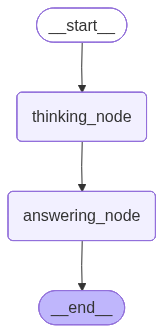

In [32]:
agent

In [33]:
agent.invoke({
    "question" : "Hello how r u "
})

{'question': 'Hello how r u ', 'answer': 'Ok Good answer', 'notes': 'starting with browswer'}


{'answer': 'Ok Good answer'}